In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def generate_signal(f, fs, duration):
    t = np.arange(0, duration, 1/fs)
    x = np.sin(2 * np.pi * f * t)
    return x

In [4]:
def delay_signal(x, d):
    y = np.zeros(len(x))
    y[d:] = x[:-d]
    return y

In [5]:
def cross_correlation(x, y):
    return np.correlate(x, y, mode='full')

In [6]:
def find_delay(R, N):
    lags = np.arange(-N+1, N)
    delay = lags[np.argmax(R)]
    return delay, lags

In [7]:
def plot_all(x, y, R, lags):
    plt.figure(figsize=(10,6))
    
    plt.subplot(3,1,1)
    plt.plot(x)
    plt.title("Original Signal")
    plt.grid()
    
    plt.subplot(3,1,2)
    plt.plot(y)
    plt.title("Delayed Signal")
    plt.grid()
    
    plt.subplot(3,1,3)
    plt.plot(lags, R)
    plt.title("Cross-Correlation")
    plt.xlabel("Lag")
    plt.grid()
    
    plt.tight_layout()
    plt.show()

Detected delay: -10


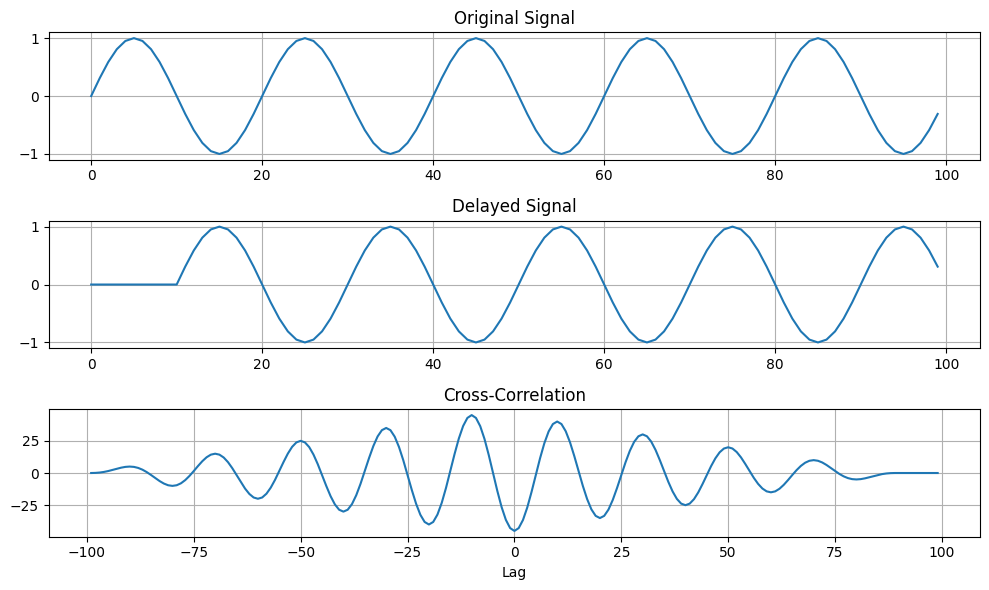

In [8]:
fs = 100
f = 5
duration = 1
delay_samples = 10

x = generate_signal(f, fs, duration)
y = delay_signal(x, delay_samples)

R = cross_correlation(x, y)

delay, lags = find_delay(R, len(x))

print("Detected delay:", delay)

plot_all(x, y, R, lags)

In [13]:
a = [1,2,3,4,5,6,7,8,9,7,6,5,4,3,22,1]
delay, lags = find_delay(a, 8)
print(delay, lags)

7 [-7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7]
